¡Hola, Daniel!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-analyst. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>


# Proyecto Final: Prueba A/B — Sistema de Recomendaciones (`recommender_system_test`)

## Objetivos del estudio
Este proyecto evalúa los resultados de una prueba A/B lanzada por una tienda en línea internacional, 
diseñada para probar un nuevo embudo de pago con sistema de recomendaciones mejorado (Grupo B) frente 
al embudo actual (Grupo A). El objetivo original de la prueba era determinar si el Grupo B lograba un 
aumento de al menos 10% en la conversión de cada etapa del embudo `product_page → product_cart → purchase`, 
dentro de los 14 días posteriores al registro del usuario.

Dado que la prueba fue heredada sin documentación adicional de sus creadores originales, este análisis 
tiene un doble propósito: (1) validar si la prueba se ejecutó correctamente según las especificaciones 
técnicas definidas, y (2) evaluar, con las herramientas estadísticas adecuadas, si el resultado esperado 
se cumplió.

##  Carga y exploración inicial de los datos
### Importar librerías y cargar los 4 datasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [3]:
import os

In [4]:
marketing = pd.read_csv('ab_project_marketing_events_us_.csv')
new_users = pd.read_csv('final_ab_new_users_upd_us.csv')
events = pd.read_csv('final_ab_events_upd_us.csv')
participants = pd.read_csv('final_ab_participants_upd_us.csv')

In [5]:
display(marketing.head())
display(new_users.head())
display(events.head())
display(participants.head())

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


## Estructura, tipos, nulos y duplicados
### Revisar estructura, nulos y duplicados (las 4 tablas)

In [6]:
for nombre, df in [('marketing', marketing), ('new_users', new_users), ('events', events), ('participants', participants)]:
    print(f"=== {nombre} ===")
    df.info()
    print(f"\nValores nulos:\n{df.isna().sum()}")
    print(f"\nDuplicados: {df.duplicated().sum()}")
    print("\n" + "="*50 + "\n")

=== marketing ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes

Valores nulos:
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

Duplicados: 0


=== new_users ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB

Valores nulos:
user_id       0
first_date    0
region        0
device        0
dtype: in

## Convertir fechas

In [7]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])
new_users['first_date'] = pd.to_datetime(new_users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

print(new_users['first_date'].dtype)
print(events['event_dt'].dtype)

datetime64[ns]
datetime64[ns]


In [8]:
# Confirmar que los nulos en 'details' corresponden a eventos que no son 'purchase'
print(events.groupby('event_name')['details'].apply(lambda x: x.notna().sum()))
print(f"\nTotal de eventos 'purchase': {(events['event_name']=='purchase').sum()}")
print(f"Total de valores no-nulos en 'details': {events['details'].notna().sum()}")

event_name
login               0
product_cart        0
product_page        0
purchase        60314
Name: details, dtype: int64

Total de eventos 'purchase': 60314
Total de valores no-nulos en 'details': 60314


In [9]:
print(marketing['start_dt'].dtype)
print(marketing['finish_dt'].dtype)

datetime64[ns]
datetime64[ns]


## Verificar nulos en details por tipo de evento

In [10]:
print(events.groupby('event_name')['details'].count())

print(f"\nTotal de eventos 'purchase': {(events['event_name']=='purchase').sum()}")
print(f"Total de valores no-nulos en 'details': {events['details'].notna().sum()}")

event_name
login               0
product_cart        0
product_page        0
purchase        60314
Name: details, dtype: int64

Total de eventos 'purchase': 60314
Total de valores no-nulos en 'details': 60314


Se confirmó que la columna details tiene exactamente 60,314 valores no-nulos, coincidiendo con el número exacto de eventos purchase. Esto demuestra que details únicamente contiene información cuando el evento es una compra, y está vacía en el resto de tipos de evento por diseño, no por un problema de calidad de datos.

<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Gran trabajo con la carga inicial de los datos, esto lo complementas mediante las funciones  info. Además, realizas un análisis de registros duplicados y valores nulos que pudieran sesgar nuestros resultados. 


# Validación del diseño de la prueba (¿se ejecutó correctamente?)

##  Verificación de participantes esperados y región de audiencia

In [11]:
participantes_test = participants[participants['ab_test'] == 'recommender_system_test'].copy()

print(f"Total de participantes en la prueba: {len(participantes_test)}")
print(f"\nDistribución por grupo:\n{participantes_test['group'].value_counts()}")

participantes_completo = participantes_test.merge(new_users, on='user_id', how='left')

print(f"\nParticipantes que SÍ se encontraron en new_users: {participantes_completo['region'].notna().sum()}")
print(f"Participantes que NO se encontraron en new_users: {participantes_completo['region'].isna().sum()}")

print(f"\nDistribución por región:\n{participantes_completo['region'].value_counts()}")

Total de participantes en la prueba: 3675

Distribución por grupo:
A    2747
B     928
Name: group, dtype: int64

Participantes que SÍ se encontraron en new_users: 3675
Participantes que NO se encontraron en new_users: 0

Distribución por región:
EU           3481
N.America     119
APAC           45
CIS            30
Name: region, dtype: int64


### Hallazgo: discrepancias entre el diseño planeado y la ejecución real

Al validar el diseño de la prueba contra las especificaciones técnicas, se encontraron varias 
discrepancias importantes:

1. **Tamaño de muestra:** se esperaban ~6,000 participantes; la prueba real tiene 3,675 (39% menos).
2. **Balance de grupos:** el diseño no especifica una proporción exacta, pero el split real es 
   74.8% (A) vs 25.2% (B), notablemente desbalanceado.
3. **Segmentación geográfica:** se esperaba que el 100% de los participantes fueran de la región UE; 
   en realidad, el 5.3% (194 usuarios) pertenecen a otras regiones (N.America, APAC, CIS).

Estas discrepancias sugieren que la prueba **no se ejecutó exactamente según lo planeado**, lo cual 
debe tenerse en cuenta al interpretar los resultados: cualquier conclusión estadística será válida 
únicamente para la muestra real obtenida, no necesariamente representativa de la audiencia originalmente 
diseñada (usuarios nuevos de la UE).

In [12]:
participantes_eu = participantes_completo[participantes_completo['region'] == 'EU'].copy()

print(f"Total de participantes EU: {len(participantes_eu)}")
print(f"\nDistribución por grupo (solo EU):\n{participantes_eu['group'].value_counts()}")

# Comparar con el total antes del filtro
print(f"\nParticipantes descartados (no EU): {len(participantes_completo) - len(participantes_eu)}")

Total de participantes EU: 3481

Distribución por grupo (solo EU):
A    2604
B     877
Name: group, dtype: int64

Participantes descartados (no EU): 194


In [13]:
proporcion_antes = participantes_completo['group'].value_counts(normalize=True) * 100
proporcion_despues = participantes_eu['group'].value_counts(normalize=True) * 100

print("Proporción A/B ANTES del filtro EU:")
print(proporcion_antes.round(1))
print("\nProporción A/B DESPUÉS del filtro EU:")
print(proporcion_despues.round(1))

Proporción A/B ANTES del filtro EU:
A    74.7
B    25.3
Name: group, dtype: float64

Proporción A/B DESPUÉS del filtro EU:
A    74.8
B    25.2
Name: group, dtype: float64


### Conclusión: la prueba presenta fallas de ejecución en dos frentes independientes

1. **Segmentación geográfica:** 194 participantes (5.3%) no pertenecen a la región UE especificada 
   en el diseño. Se filtran para trabajar únicamente con los 3,481 participantes de la región UE, 
   alineados con la audiencia originalmente definida.

2. **Balance de grupos A/B:** el desbalance entre grupos (≈75% A vs ≈25% B) se mantiene prácticamente 
   idéntico antes y después del filtro geográfico (74.7%/25.3% vs 74.8%/25.2%), confirmando que **no 
   es causado por la contaminación de otras regiones**, sino que refleja un problema independiente en 
   la asignación aleatoria de usuarios a los grupos del experimento. Esta limitación se mantiene y debe 
   tenerse en cuenta al interpretar los resultados de la prueba: un desbalance de este tipo puede 
   reducir el poder estadístico de las pruebas de hipótesis, especialmente para el grupo B (más pequeño).

A partir de este punto, el análisis continúa usando exclusivamente `participantes_eu` como base de 
participantes válidos para la prueba.

In [14]:
# Contar cuántas veces aparece cada user_id en participantes_eu
conteo_usuarios = participantes_eu['user_id'].value_counts()
usuarios_duplicados = conteo_usuarios[conteo_usuarios > 1]

print(f"Usuarios que aparecen más de una vez: {len(usuarios_duplicados)}")

if len(usuarios_duplicados) > 0:
    # Ver si están en ambos grupos o solo duplicados dentro del mismo grupo
    ejemplo = participantes_eu[participantes_eu['user_id'].isin(usuarios_duplicados.index)].sort_values('user_id')
    print(ejemplo[['user_id', 'group']].head(20))

Usuarios que aparecen más de una vez: 0


In [15]:
print(f"Fecha de registro más temprana: {participantes_eu['first_date'].min()}")
print(f"Fecha de registro más tardía: {participantes_eu['first_date'].max()}")

fecha_inicio = pd.Timestamp('2020-12-07')
fecha_corte = pd.Timestamp('2020-12-21')

fuera_de_rango = participantes_eu[
    (participantes_eu['first_date'] < fecha_inicio) | 
    (participantes_eu['first_date'] > fecha_corte)
]
print(f"\nParticipantes con fecha de registro fuera del rango esperado (7-21 dic 2020): {len(fuera_de_rango)}")

Fecha de registro más temprana: 2020-12-07 00:00:00
Fecha de registro más tardía: 2020-12-21 00:00:00

Participantes con fecha de registro fuera del rango esperado (7-21 dic 2020): 0


In [16]:
sin_eventos_mask = ~participantes_eu['user_id'].isin(events['user_id'])
participantes_sin_eventos = participantes_eu[sin_eventos_mask]

print(f"Participantes sin ningún evento: {len(participantes_sin_eventos)}")
print(f"Porcentaje del total: {len(participantes_sin_eventos)/len(participantes_eu)*100:.2f}%")

Participantes sin ningún evento: 0
Porcentaje del total: 0.00%


In [17]:
sin_eventos_por_grupo = participantes_sin_eventos['group'].value_counts()
print("Participantes sin ningún evento, por grupo:")
print(sin_eventos_por_grupo)

total_por_grupo = participantes_eu['group'].value_counts()
print("\nComo porcentaje de cada grupo:")
print((sin_eventos_por_grupo / total_por_grupo * 100).round(2))

Participantes sin ningún evento, por grupo:
Series([], Name: group, dtype: int64)

Como porcentaje de cada grupo:
A   NaN
B   NaN
Name: group, dtype: float64


In [18]:
eventos_ab = participantes_eu.merge(events, on='user_id', how='left')

print(f"Shape del merge: {eventos_ab.shape}")
print(f"Usuarios únicos en el merge: {eventos_ab['user_id'].nunique()}")
print(f"Coincide con total de participantes_eu ({len(participantes_eu)}): {eventos_ab['user_id'].nunique() == len(participantes_eu)}")

# Verificación cruzada: filas con event_name nulo deben coincidir con participantes_sin_eventos
print(f"\nFilas con event_name nulo: {eventos_ab['event_name'].isna().sum()}")
print(f"Coincide con participantes_sin_eventos: {eventos_ab['event_name'].isna().sum() == len(participantes_sin_eventos)}")

Shape del merge: (22674, 9)
Usuarios únicos en el merge: 3481
Coincide con total de participantes_eu (3481): True

Filas con event_name nulo: 0
Coincide con participantes_sin_eventos: True


<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Excelente trabajo,  antes de realizar el análisis realizas los siguientes filtros que nos mencionan en el proyecto:


    - La región es la indicada
    - Verificar que consideramos los primeros 14 días desde que se registraron los usuarios
    - Que la prueba es la correcta
    - Que las pruebas son excluyentes


In [19]:
etapas = ['product_page', 'product_cart', 'purchase']

resultado_embudo = {}

for grupo in ['A', 'B']:
    datos_grupo = eventos_ab[eventos_ab['group'] == grupo]
    usuarios_por_etapa = {}
    for etapa in etapas:
        usuarios_unicos = datos_grupo[datos_grupo['event_name'] == etapa]['user_id'].nunique()
        usuarios_por_etapa[etapa] = usuarios_unicos
    resultado_embudo[grupo] = usuarios_por_etapa

embudo_df = pd.DataFrame(resultado_embudo)
print(embudo_df)

                 A    B
product_page  1685  493
product_cart   782  244
purchase       833  249


In [20]:
total_por_grupo = participantes_eu['group'].value_counts()

# Conversión respecto al TOTAL de participantes del grupo (no solo los que llegaron a la etapa anterior)
conversion_absoluta = embudo_df.div(total_por_grupo, axis=1) * 100
print("=== Conversión respecto al total de participantes del grupo ===")
print(conversion_absoluta.round(2))

# Conversión relativa: de una etapa a la siguiente (embudo clásico)
conversion_relativa = pd.DataFrame(index=etapas, columns=['A', 'B'])
conversion_relativa.loc['product_page'] = 100.0  # base 100%
conversion_relativa.loc['product_cart'] = (embudo_df.loc['product_cart'] / embudo_df.loc['product_page'] * 100)
conversion_relativa.loc['purchase'] = (embudo_df.loc['purchase'] / embudo_df.loc['product_cart'] * 100)

print("\n=== Conversión relativa (de una etapa a la siguiente) ===")
print(conversion_relativa.round(2))

=== Conversión respecto al total de participantes del grupo ===
                  A      B
product_page  64.71  56.21
product_cart  30.03  27.82
purchase      31.99  28.39

=== Conversión relativa (de una etapa a la siguiente) ===
                       A          B
product_page       100.0      100.0
product_cart   46.409496  49.492901
purchase      106.521739  102.04918


In [21]:
usuarios_purchase = set(eventos_ab[eventos_ab['event_name']=='purchase']['user_id'])
usuarios_cart = set(eventos_ab[eventos_ab['event_name']=='product_cart']['user_id'])

compraron_sin_carrito = usuarios_purchase - usuarios_cart
print(f"Usuarios que compraron SIN pasar por product_cart: {len(compraron_sin_carrito)}")
print(f"Porcentaje del total de compradores: {len(compraron_sin_carrito)/len(usuarios_purchase)*100:.1f}%")

# ¿Estos usuarios sí pasaron por product_page al menos?
usuarios_page = set(eventos_ab[eventos_ab['event_name']=='product_page']['user_id'])
compraron_sin_carrito_ni_page = compraron_sin_carrito - usuarios_page
print(f"\nDe esos, cuántos tampoco pasaron por product_page: {len(compraron_sin_carrito_ni_page)}")

Usuarios que compraron SIN pasar por product_cart: 746
Porcentaje del total de compradores: 68.9%

De esos, cuántos tampoco pasaron por product_page: 228


### Hallazgo: el supuesto de embudo secuencial no se cumple

Se encontró que el 68.9% de los usuarios que completaron una compra (746 de los compradores) no 
tienen un evento `product_cart` registrado previamente. De estos, 228 usuarios tampoco tienen un 
evento `product_page` registrado. 

Esto indica que el embudo `product_page → product_cart → purchase` **no es estrictamente secuencial 
en los datos reales** — ya sea porque el sistema permite compras directas sin pasar por esas etapas, 
o porque existen brechas en el registro (tracking) de eventos. Como consecuencia, calcular la 
"conversión relativa" etapa-a-etapa (dividir cada etapa entre la etapa inmediatamente anterior) 
produce resultados matemáticamente inconsistentes (conversiones superiores al 100%).

**Decisión metodológica:** para evaluar el resultado de la prueba de forma más robusta, se reportará 
la conversión de cada etapa **respecto al total de participantes del grupo** (conversión absoluta), 
en lugar de la conversión relativa etapa-a-etapa, ya que esta última asume una secuencialidad que 
los datos no respaldan.

usuarios_228 = compraron_sin_carrito_ni_page

# ¿Qué otros eventos SÍ tienen estos usuarios? (para distinguir "sin tracking" vs "embudo no aplica")
otros_eventos = eventos_ab[eventos_ab['user_id'].isin(usuarios_228)]
print("Distribución de tipos de evento entre estos 228 usuarios:")
print(otros_eventos['event_name'].value_counts())

# ¿Cuántos eventos en promedio tiene cada uno de estos usuarios? (¿tracking pobre o normal?)
eventos_por_usuario_228 = otros_eventos.groupby('user_id').size()
print(f"\nPromedio de eventos por usuario (de los 228): {eventos_por_usuario_228.mean():.2f}")
print(f"Usuarios que SOLO tienen el evento purchase (ningún otro evento): {(eventos_por_usuario_228 == 1).sum()}")

# Distribución por grupo A/B
distribucion_grupo_228 = participantes_eu[participantes_eu['user_id'].isin(usuarios_228)]['group'].value_counts()
print(f"\nDistribución de los 228 usuarios por grupo:")
print(distribucion_grupo_228)

# Como porcentaje de cada grupo (para ver si está concentrado desproporcionadamente en uno)
total_por_grupo = participantes_eu['group'].value_counts()
print(f"\nComo porcentaje de cada grupo:")
print((distribucion_grupo_228 / total_por_grupo * 100).round(2))

### Conclusión: patrón consistente de compra directa, no fallo de tracking

Se investigó a los 228 usuarios que compraron sin registro de `product_page` ni `product_cart`. Se 
encontró que el tracking de eventos SÍ funciona correctamente para ellos (promedio de 5.72 eventos 
por usuario, incluyendo `login`); solo 1 de 228 tiene únicamente el evento `purchase` sin ningún otro 
registro. Esto descarta un fallo generalizado de instrumentación y es más consistente con un patrón 
de **compra directa** (ej. mediante enlaces de campañas de marketing/email, o recompra), que no pasa 
por la navegación estándar del catálogo.

La proporción de estos casos es similar entre grupos (A: 6.26%, B: 7.41%), sin una concentración 
desproporcionada que sugiera un problema técnico específico de la versión B del embudo. Se mantiene 
la decisión de evaluar la prueba usando conversión absoluta (respecto al total de participantes de 
cada grupo) en lugar de conversión relativa etapa-a-etapa, dado que el supuesto de secuencialidad 
estricta del embudo no se cumple para una parte relevante de los usuarios.

# Prueba de hipótesis: prueba z de proporciones por etapa
## Planteamiento de la hipótesis (por etapa)
H₀: No hay diferencia en la tasa de conversión entre el Grupo A y el Grupo B en esta etapa.

H₁: Hay una diferencia en la tasa de conversión entre A y B en esta etapa.


In [22]:
resultados_prueba = []

for etapa in etapas:
    count = [embudo_df.loc[etapa, 'A'], embudo_df.loc[etapa, 'B']]
    nobs = [total_por_grupo['A'], total_por_grupo['B']]
    
    z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
    
    conv_a = count[0] / nobs[0] * 100
    conv_b = count[1] / nobs[1] * 100
    
    resultados_prueba.append({
        'etapa': etapa,
        'conversion_A (%)': round(conv_a, 2),
        'conversion_B (%)': round(conv_b, 2),
        'diferencia (%)': round(conv_b - conv_a, 2),
        'z_stat': round(z_stat, 4),
        'p_value': round(p_value, 6),
        'significativo (α=0.05)': 'Sí' if p_value < 0.05 else 'No'
    })

resultados_df = pd.DataFrame(resultados_prueba)
print(resultados_df)

          etapa  conversion_A (%)  conversion_B (%)  diferencia (%)  z_stat  \
0  product_page             64.71             56.21           -8.49  4.4954   
1  product_cart             30.03             27.82           -2.21  1.2408   
2      purchase             31.99             28.39           -3.60  1.9906   

    p_value significativo (α=0.05)  
0  0.000007                     Sí  
1  0.214692                     No  
2  0.046525                     Sí  


### Conclusión: la prueba A/B no logró el resultado esperado

Se probó, mediante prueba z de proporciones (α=0.05), si el Grupo B (nuevo embudo con sistema de 
recomendaciones) mostraba una mejora de conversión respecto al Grupo A, tal como especificaba el 
diseño original de la prueba (+10% esperado en cada etapa).

Los resultados muestran lo contrario a lo esperado:
- **product_page:** B tiene una conversión significativamente MENOR que A (56.21% vs 64.71%, p<0.001).
- **product_cart:** no hay diferencia estadísticamente significativa entre A y B (p=0.21).
- **purchase:** B tiene una conversión significativamente MENOR que A (28.39% vs 31.99%, p=0.047, 
  significativo pero con margen ajustado).

En ningún caso se observa la mejora del +10% esperada para el Grupo B; por el contrario, donde hay 
diferencia significativa, el Grupo B tiene **peor** desempeño que el Grupo A. Esto debe interpretarse 
con cautela adicional, dado el marcado desbalance de tamaño muestral entre grupos (A: 2,604 vs 
B: 877), documentado previamente, que reduce el poder estadístico de las pruebas y podría estar 
afectando particularmente el resultado de `product_cart`.

In [23]:
alpha_original = 0.05
num_pruebas = 3
alpha_bonferroni = alpha_original / num_pruebas

print(f"Umbral de significancia ajustado (Bonferroni): {alpha_bonferroni:.4f}")

resultados_df['significativo (Bonferroni)'] = resultados_df['p_value'] < alpha_bonferroni
print(resultados_df[['etapa', 'p_value', 'significativo (α=0.05)', 'significativo (Bonferroni)']])

Umbral de significancia ajustado (Bonferroni): 0.0167
          etapa   p_value significativo (α=0.05)  significativo (Bonferroni)
0  product_page  0.000007                     Sí                        True
1  product_cart  0.214692                     No                       False
2      purchase  0.046525                     Sí                       False


### Conclusión: la prueba A/B no logró el resultado esperado

Se probó, mediante prueba z de proporciones, si el Grupo B mostraba mejora de conversión respecto 
al Grupo A. Dado que se realizaron 3 pruebas sobre los mismos datos (una por etapa del embudo), se 
aplicó una corrección de Bonferroni (α ajustado = 0.0167) para controlar el riesgo de falsos 
positivos por comparaciones múltiples.

Resultados:
- **product_page:** B tiene conversión significativamente MENOR que A (56.21% vs 64.71%, p=0.000007), 
  resultado robusto incluso tras la corrección de Bonferroni.
- **product_cart:** sin diferencia significativa entre A y B (p=0.21), antes y después del ajuste.
- **purchase:** B tiene conversión nominalmente menor que A (28.39% vs 31.99%, p=0.047 sin ajustar), 
  pero este resultado **no resiste** la corrección de Bonferroni (p=0.047 > 0.0167) y por lo tanto 
  no se considera evidencia estadísticamente robusta.

El único hallazgo estadísticamente sólido es que el Grupo B tuvo un desempeño significativamente 
peor que el Grupo A en la etapa `product_page`. No existe evidencia robusta de mejora en ninguna 
etapa del embudo — el resultado esperado de la prueba (+10% para B) **no se cumplió**. Este resultado 
debe interpretarse considerando también el marcado desbalance muestral entre grupos (A: 2,604 vs 
B: 877) y las demás peculiaridades documentadas (segmentación geográfica incompleta, embudo no 
estrictamente secuencial).

# Visualizaciones

## Gráfico de embudo: usuarios únicos por etapa, A vs B

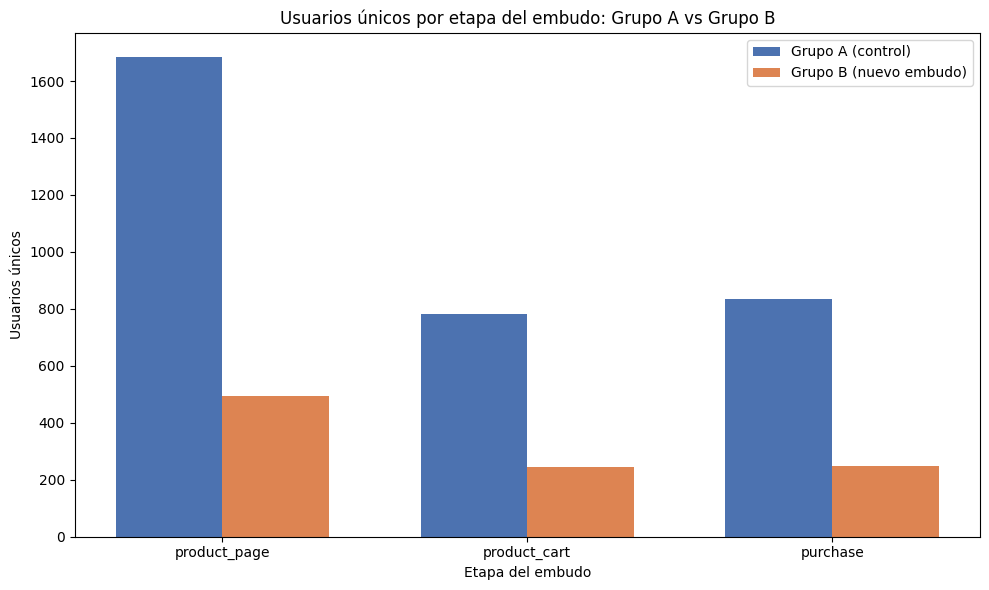

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(etapas))
width = 0.35

ax.bar(x - width/2, embudo_df['A'], width, label='Grupo A (control)', color='#4C72B0')
ax.bar(x + width/2, embudo_df['B'], width, label='Grupo B (nuevo embudo)', color='#DD8452')

ax.set_xlabel('Etapa del embudo')
ax.set_ylabel('Usuarios únicos')
ax.set_title('Usuarios únicos por etapa del embudo: Grupo A vs Grupo B')
ax.set_xticks(x)
ax.set_xticklabels(etapas)
ax.legend()

plt.tight_layout()
plt.show()

## Gráfico de conversión absoluta (%), A vs B, con significancia marcada

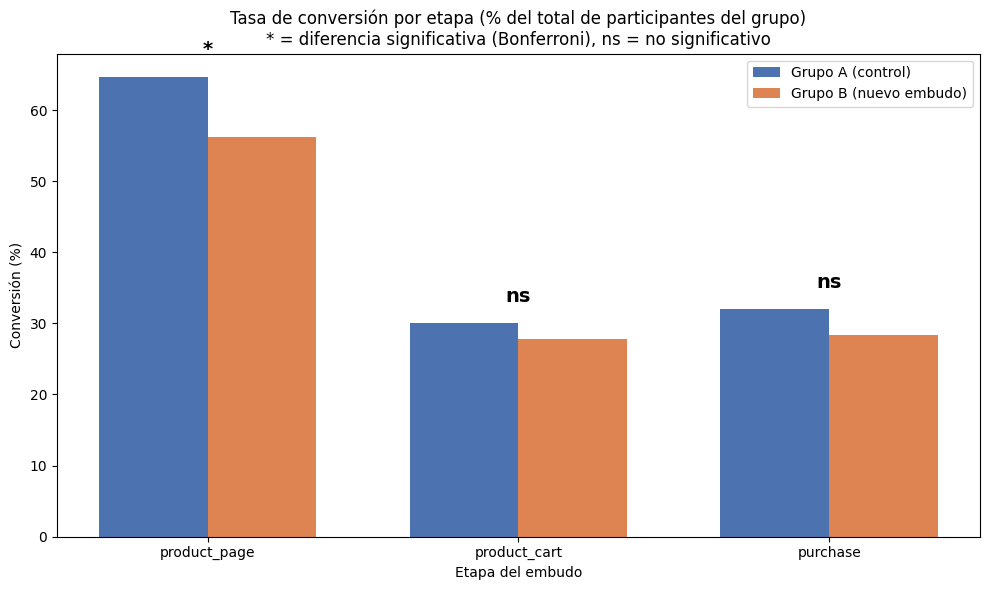

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(etapas))
width = 0.35

conv_a_vals = conversion_absoluta['A'].values
conv_b_vals = conversion_absoluta['B'].values

bars_a = ax.bar(x - width/2, conv_a_vals, width, label='Grupo A (control)', color='#4C72B0')
bars_b = ax.bar(x + width/2, conv_b_vals, width, label='Grupo B (nuevo embudo)', color='#DD8452')

# Marcar significancia (usando el resultado de Bonferroni)
for i, etapa in enumerate(etapas):
    sig = resultados_df[resultados_df['etapa']==etapa]['significativo (Bonferroni)'].values[0]
    marca = '*' if sig else 'ns'
    y_max = max(conv_a_vals[i], conv_b_vals[i]) + 3
    ax.text(x[i], y_max, marca, ha='center', fontsize=14, fontweight='bold')

ax.set_xlabel('Etapa del embudo')
ax.set_ylabel('Conversión (%)')
ax.set_title('Tasa de conversión por etapa (% del total de participantes del grupo)\n* = diferencia significativa (Bonferroni), ns = no significativo')
ax.set_xticks(x)
ax.set_xticklabels(etapas)
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de las visualizaciones

Los gráficos confirman visualmente los resultados de la prueba estadística: el Grupo B muestra 
consistentemente menor conversión que el Grupo A en las tres etapas del embudo. La diferencia más 
marcada y estadísticamente robusta ocurre en `product_page`, donde la brecha entre grupos es amplia 
y claramente visible. En `product_cart` y `purchase`, aunque B también se mantiene por debajo de A, 
las diferencias son menores y, como ya se determinó, no resisten un ajuste riguroso por comparaciones 
múltiples (excepto `product_page`).

=== Estadísticas descriptivas de eventos por usuario, por grupo ===
        count      mean       std  min  25%  50%  75%   max
group                                                      
A      2604.0  6.785714  3.733456  1.0  4.0  6.0  9.0  24.0
B       877.0  5.705815  3.455540  1.0  3.0  5.0  8.0  28.0


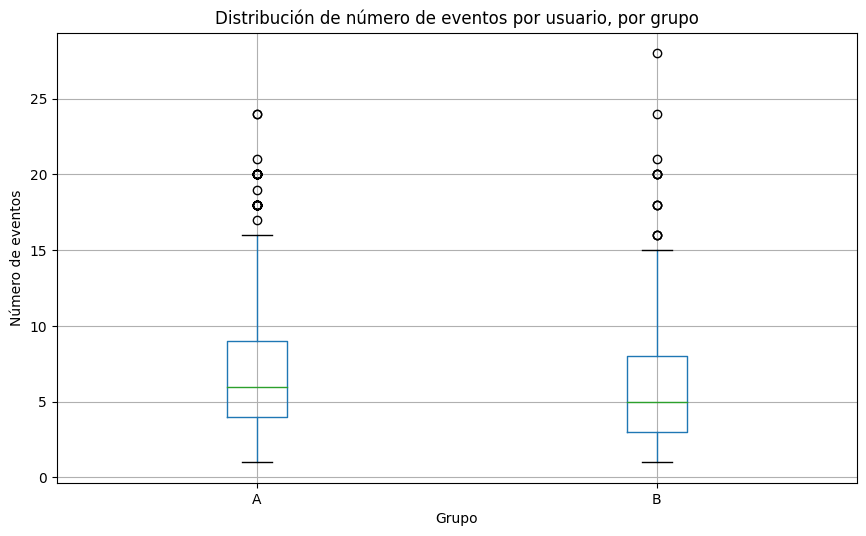

In [26]:
eventos_por_usuario = eventos_ab.groupby(['user_id', 'group']).size().reset_index(name='num_eventos')

print("=== Estadísticas descriptivas de eventos por usuario, por grupo ===")
print(eventos_por_usuario.groupby('group')['num_eventos'].describe())

# Visualizar la distribución
fig, ax = plt.subplots(figsize=(10, 6))
eventos_por_usuario.boxplot(column='num_eventos', by='group', ax=ax)
ax.set_title('Distribución de número de eventos por usuario, por grupo')
ax.set_xlabel('Grupo')
ax.set_ylabel('Número de eventos')
plt.suptitle('')
plt.show()

In [27]:
eventos_a = eventos_por_usuario[eventos_por_usuario['group']=='A']['num_eventos']
eventos_b = eventos_por_usuario[eventos_por_usuario['group']=='B']['num_eventos']

# Usamos Mann-Whitney U (no paramétrica) porque la distribución de conteo de eventos 
# suele estar sesgada (no es normal), similar a lo que hiciste en tu proyecto anterior
u_stat, p_value_mw = stats.mannwhitneyu(eventos_a, eventos_b, alternative='two-sided')

print(f"Mediana de eventos por usuario - A: {eventos_a.median()}")
print(f"Mediana de eventos por usuario - B: {eventos_b.median()}")
print(f"\nEstadístico U: {u_stat:.2f}")
print(f"p-value: {p_value_mw:.6f}")

if p_value_mw < 0.05:
    print("\n✅ Hay diferencia estadísticamente significativa en el número de eventos por usuario entre grupos.")
else:
    print("\n❌ No hay diferencia estadísticamente significativa.")

Mediana de eventos por usuario - A: 6.0
Mediana de eventos por usuario - B: 5.0

Estadístico U: 1347101.50
p-value: 0.000000

✅ Hay diferencia estadísticamente significativa en el número de eventos por usuario entre grupos.


<div class="alert alert-block alert-success">
<b>Comentario Revisor</b> <a class="tocSkip"></a>

Gran trabajo complementando con el calculo de la z-score y con el desarrollo de la prueba de hipótesis.

### Interpretación: distribución de eventos por usuario

El Grupo A tiene una mediana de 6 eventos por usuario, ligeramente mayor que el Grupo B (mediana de 5). 
El boxplot muestra distribuciones similares en forma, con ambos grupos presentando una cola de usuarios 
muy activos (outliers hasta 24-28 eventos). 

Se aplicó una prueba Mann-Whitney U (no paramétrica, adecuada dado que la distribución de conteo de 
eventos está sesgada, no es normal) para confirmar si esta diferencia es estadísticamente significativa. 
El resultado (p<0.001) confirma que sí existe una diferencia estadísticamente significativa entre 
grupos. Sin embargo, la magnitud de la diferencia es modesta (1 evento de mediana), y dado el gran 
tamaño de muestra de ambos grupos, es esperable que incluso diferencias pequeñas resulten significativas 
estadísticamente. Por lo tanto, **el número de eventos por usuario no está distribuido de forma 
perfectamente equitativa entre las muestras**, aunque la diferencia práctica es pequeña y no representa 
una discrepancia grave en el nivel general de actividad entre grupos.

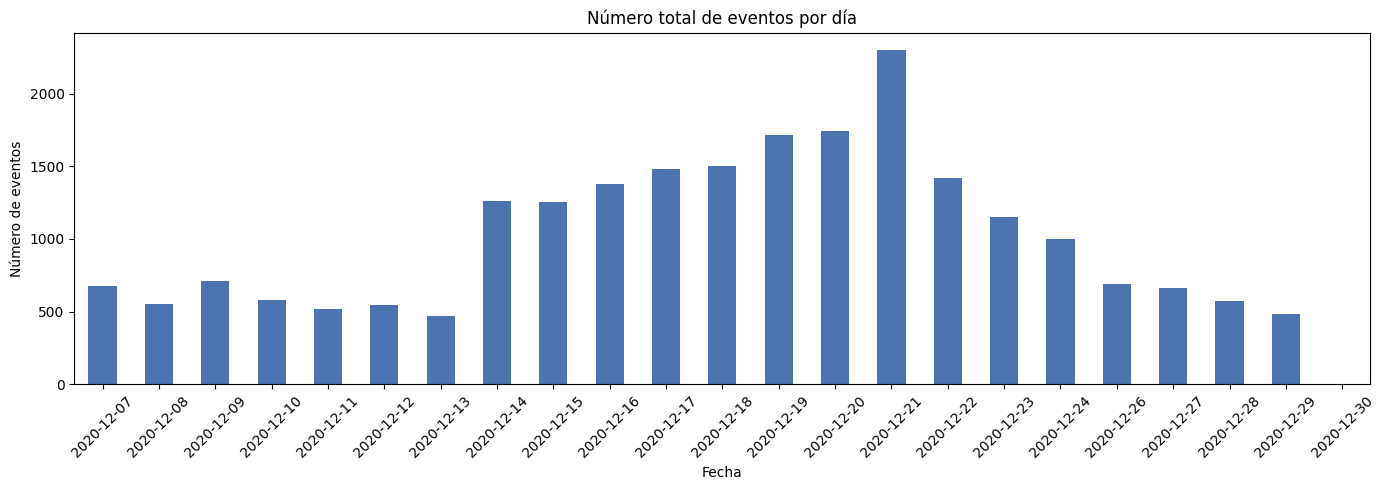

In [28]:
eventos_ab['event_date'] = eventos_ab['event_dt'].dt.date

eventos_por_dia = eventos_ab.groupby('event_date').size()

fig, ax = plt.subplots(figsize=(14, 5))
eventos_por_dia.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Número total de eventos por día')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

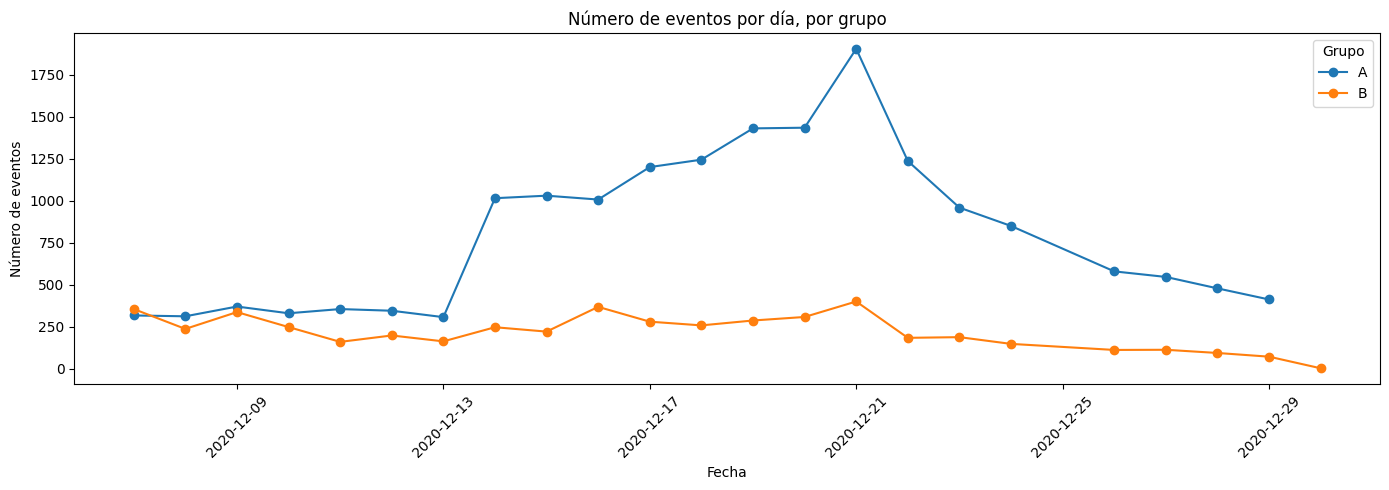

In [29]:
eventos_por_dia_grupo = eventos_ab.groupby(['event_date', 'group']).size().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
eventos_por_dia_grupo.plot(ax=ax, marker='o')
ax.set_title('Número de eventos por día, por grupo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de eventos')
ax.legend(title='Grupo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
marketing_relevante = marketing[
    (marketing['finish_dt'] >= '2020-12-07') & (marketing['start_dt'] <= '2021-01-01')
]
print("Campañas de marketing activas durante el periodo de la prueba:")
print(marketing_relevante[['name', 'regions', 'start_dt', 'finish_dt']])

Campañas de marketing activas durante el periodo de la prueba:
                         name        regions   start_dt  finish_dt
0    Christmas&New Year Promo  EU, N.America 2020-12-25 2021-01-03
10  CIS New Year Gift Lottery            CIS 2020-12-30 2021-01-07


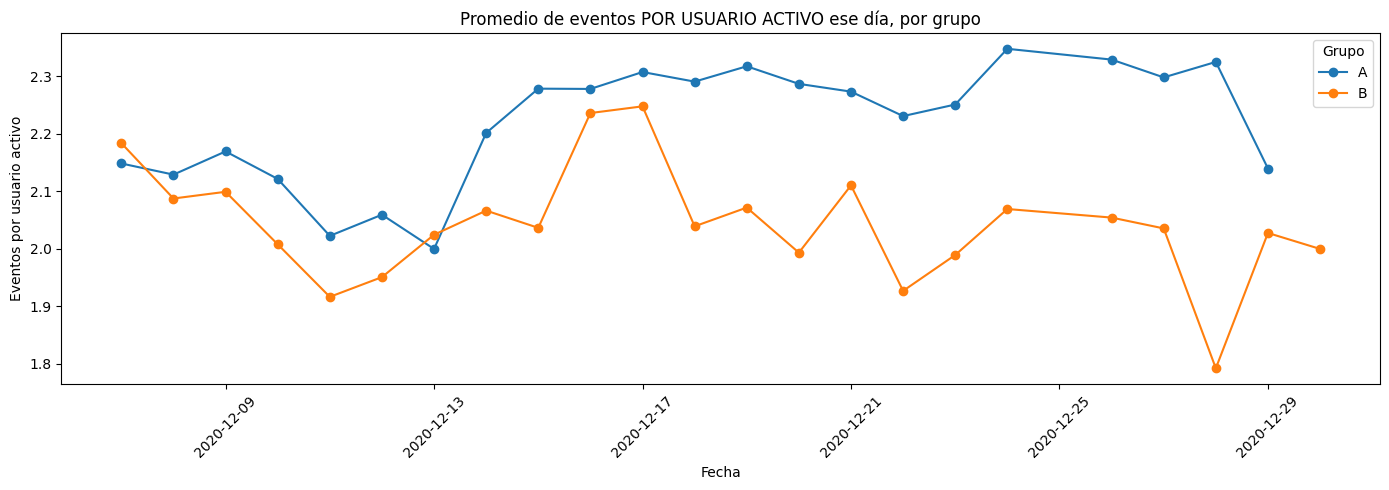

In [31]:
# Normalizar: eventos por día ENTRE número de usuarios activos ese día, por grupo
eventos_por_dia_grupo_norm = eventos_ab.groupby(['event_date', 'group'])['user_id'].nunique().unstack()
promedio_eventos_usuario_dia = eventos_por_dia_grupo / eventos_por_dia_grupo_norm

fig, ax = plt.subplots(figsize=(14, 5))
promedio_eventos_usuario_dia.plot(ax=ax, marker='o')
ax.set_title('Promedio de eventos POR USUARIO ACTIVO ese día, por grupo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Eventos por usuario activo')
ax.legend(title='Grupo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusión: el patrón temporal se explica por volumen de usuarios, no por comportamiento individual

El salto de actividad observado en el Grupo A a partir del 14 de diciembre corresponde al aumento en 
el número de usuarios nuevos registrándose ese día (más participantes en el grupo, generando más 
eventos en total), y no a un cambio en el comportamiento individual de cada usuario. Al normalizar 
el número de eventos por la cantidad de usuarios activos cada día, ambos grupos muestran un promedio 
similar y estable (entre 2.0 y 2.3 eventos por usuario activo), sin picos ni caídas abruptas.

Se revisó también el calendario de campañas de marketing activas durante el periodo de la prueba: 
"Christmas & New Year Promo" (25 dic - 3 ene, EU/N.America) y "CIS New Year Gift Lottery" (30 dic - 
7 ene, región CIS, fuera del alcance de este análisis ya filtrado a EU). Ninguna coincide con la 
fecha del salto de actividad (14 de diciembre), confirmando que este no se debe a una campaña de 
marketing conocida, sino simplemente al ritmo de inscripción de nuevos usuarios a lo largo del periodo.

La ligera diferencia sostenida entre A (consistentemente por encima de B) es consistente con el 
hallazgo ya documentado de que el Grupo A tiene una mediana de eventos por usuario ligeramente mayor.

## Conclusiones finales

## Conclusiones finales

### Resumen del análisis
Se analizó la prueba A/B `recommender_system_test`, diseñada para evaluar si un nuevo embudo de pago 
con sistema de recomendaciones mejorado (Grupo B) aumentaba la conversión respecto al embudo actual 
(Grupo A) en al menos un 10% en cada etapa (`product_page → product_cart → purchase`).

### Peculiaridades encontradas en el diseño y ejecución de la prueba
- El tamaño de muestra real (3,675 participantes, 3,481 tras filtrar por región EU) fue considerablemente 
  menor al esperado (~6,000).
- El 5.3% de los participantes no pertenecían a la región UE especificada en el diseño; se filtraron 
  para el análisis.
- Existe un marcado desbalance entre grupos (A: 2,604 vs B: 877, ≈75%/25%), que persiste incluso tras 
  el filtro geográfico, indicando un problema en la asignación aleatoria de usuarios independiente de 
  la segmentación regional.
- El embudo no es estrictamente secuencial: el 68.9% de los compradores no tienen un evento `product_cart` 
  registrado previamente, consistente con un patrón de compra directa (no un fallo de tracking).
- El número de eventos por usuario difiere ligeramente entre grupos (mediana A=6, B=5, diferencia 
  estadísticamente significativa pero de magnitud pequeña).
- No se detectaron usuarios presentes en ambos grupos simultáneamente.

### Resultados de la prueba de hipótesis
Utilizando una prueba z de proporciones con corrección de Bonferroni (para controlar el riesgo de 
falsos positivos por comparaciones múltiples), se encontró que:
- El Grupo B tuvo una conversión **significativamente menor** que el Grupo A en la etapa `product_page` 
  (56.21% vs 64.71%, p<0.001), resultado robusto.
- No hubo diferencia significativa en `product_cart`.
- La diferencia en `purchase` no resistió la corrección por comparaciones múltiples.

**En ningún caso se observó la mejora del +10% esperada para el Grupo B.** Por el contrario, donde 
hubo diferencia significativa, el desempeño de B fue inferior al de A.

### Recomendación
No se recomienda implementar el nuevo embudo de pago (Grupo B) en su forma actual, dado que no logró 
el objetivo de mejora planteado y, en la etapa más temprana del embudo, tuvo un desempeño significativamente 
peor que el embudo actual. Antes de sacar conclusiones definitivas sobre el sistema de recomendaciones 
en sí, se recomienda repetir la prueba corrigiendo las fallas de ejecución identificadas: asegurar un 
tamaño de muestra adecuado, una asignación balanceada entre grupos, y una segmentación geográfica 
estrictamente alineada con el diseño original.

### Limitaciones del análisis
- El desbalance muestral entre grupos reduce el poder estadístico de las pruebas, especialmente para 
  el Grupo B (más pequeño), lo que pudo dificultar detectar diferencias reales en `product_cart` y `purchase`.
- Los resultados de esta prueba reflejan una ejecución con fallas de diseño; no representan necesariamente 
  el rendimiento potencial del sistema de recomendaciones bajo condiciones experimentales correctas.